In [1]:
# Inicializar bibliotecas
import os
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

print("✅ Bibliotecas carregadas!")

✅ Bibliotecas carregadas!


In [2]:
# Carregar dados com delimitador correto
caminho_arquivo = r'D:\OneDrive\Pessoais\Doutorado\Cefet\data\bd_gta_dentro_mg202505091607.csv'

print("Carregando dados com delimitador ';'...")
# Ler apenas algumas linhas primeiro para inspecionar
df = pd.read_csv(caminho_arquivo, sep=';', nrows=100000, low_memory=False)

print(f"\n✅ Dados carregados: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"\nColunas: {list(df.columns)}")
print(f"\nPrimeiras linhas:")
print(df.head())

Carregando dados com delimitador ';'...

✅ Dados carregados: 100,000 linhas × 15 colunas

Colunas: ['nr_gta', 'nr_serie', 'id_gta', 'dt_emissao_gta', 'cod_produtor_origem', 'cod_produtor_destino', 'id_tipo_finalidade_gta', 'ds_meio_transporte', 'cod_municipio_origem', 'nome_municipio_origem', 'estado_origem', 'cod_municipio_destino', 'nome_municipio_destino', 'estado_destino', 'qtd']

Primeiras linhas:
   nr_gta nr_serie    id_gta           dt_emissao_gta  cod_produtor_origem  \
0  226276        G   6355168  2017-10-25 09:00:49.224               117741   
1  227171        K  10364742  2020-08-20 08:44:33.686               489430   
2  113366        E   4231155  2016-03-03 11:26:17.376               454490   
3  385572        F   5510400  2017-03-13 08:21:38.056               321842   
4  779122        M  12917242  2022-05-02 11:24:46.905              3149764   

   cod_produtor_destino  id_tipo_finalidade_gta ds_meio_transporte  \
0                397284                       2        

In [3]:
# Estatísticas descritivas
print("\n📊 ANÁLISE EXPLORATÓRIA")
print("="*70)
print("\nTipos de dados:")
print(df.dtypes)
print("\nValores ausentes:")
print(df.isnull().sum())
print("\nEstatísticas das colunas numéricas:")
print(df.describe())


📊 ANÁLISE EXPLORATÓRIA

Tipos de dados:
nr_gta                     int64
nr_serie                  object
id_gta                     int64
dt_emissao_gta            object
cod_produtor_origem        int64
cod_produtor_destino       int64
id_tipo_finalidade_gta     int64
ds_meio_transporte        object
cod_municipio_origem       int64
nome_municipio_origem     object
estado_origem             object
cod_municipio_destino      int64
nome_municipio_destino    object
estado_destino            object
qtd                        int64
dtype: object

Valores ausentes:
nr_gta                    0
nr_serie                  0
id_gta                    0
dt_emissao_gta            0
cod_produtor_origem       0
cod_produtor_destino      0
id_tipo_finalidade_gta    0
ds_meio_transporte        0
cod_municipio_origem      0
nome_municipio_origem     0
estado_origem             0
cod_municipio_destino     0
nome_municipio_destino    0
estado_destino            0
qtd                       0
dtype: int6

In [4]:
# Processar coluna 'qtd' (quantidade)
# Converter para numérico, removendo valores inválidos
df['qtd'] = pd.to_numeric(df['qtd'], errors='coerce')

# Remover NaN
populacao = df['qtd'].dropna().values

# Análise da distribuição
mu_pop = np.mean(populacao)
sigma_pop = np.std(populacao, ddof=0)
mediana_pop = np.median(populacao)
assimetria_pop = stats.skew(populacao)
curtose_pop = stats.kurtosis(populacao)

print("\n📌 CARACTERIZAÇÃO DA VARIÁVEL 'QTD' (Quantidade)")
print("="*70)
print(f"Observações válidas: {len(populacao):,}")
print(f"Média: {mu_pop:.4f}")
print(f"Mediana: {mediana_pop:.4f}")
print(f"Desvio padrão: {sigma_pop:.4f}")
print(f"Assimetria: {assimetria_pop:.4f}", end="")

if abs(assimetria_pop) < 0.5:
    print(" → Aproximadamente simétrica")
elif assimetria_pop > 0.5:
    print(" → Assimétrica à direita (cauda positiva)")
else:
    print(" → Assimétrica à esquerda (cauda negativa)")

print(f"Curtose: {curtose_pop:.4f}")
print(f"Mínimo: {populacao.min():.4f}")
print(f"Máximo: {populacao.max():.4f}")
print(f"Amplitude: {populacao.max() - populacao.min():.4f}")


📌 CARACTERIZAÇÃO DA VARIÁVEL 'QTD' (Quantidade)
Observações válidas: 100,000
Média: 18.8562
Mediana: 11.0000
Desvio padrão: 31.4902
Assimetria: 16.6981 → Assimétrica à direita (cauda positiva)
Curtose: 687.4347
Mínimo: 1.0000
Máximo: 2266.0000
Amplitude: 2265.0000


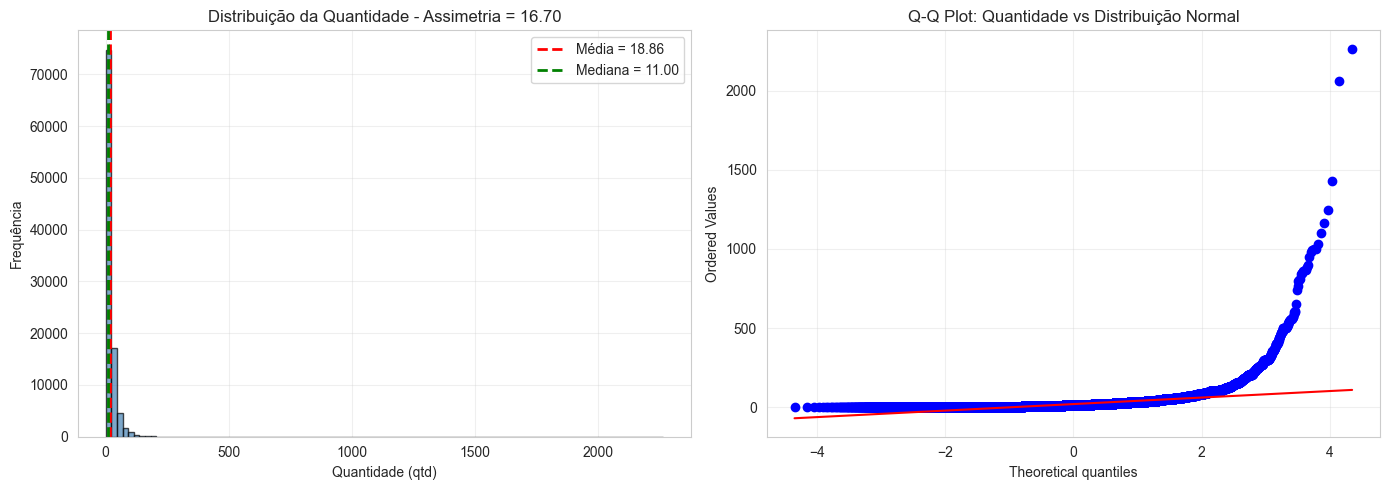

✅ Distribuição visualizada!


In [5]:
# Visualizar distribuição
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(populacao, bins=100, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(mu_pop, color='red', linestyle='--', linewidth=2, label=f'Média = {mu_pop:.2f}')
axes[0].axvline(mediana_pop, color='green', linestyle='--', linewidth=2, label=f'Mediana = {mediana_pop:.2f}')
axes[0].set_xlabel('Quantidade (qtd)')
axes[0].set_ylabel('Frequência')
axes[0].set_title(f'Distribuição da Quantidade - Assimetria = {assimetria_pop:.2f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Q-Q Plot
stats.probplot(populacao, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Quantidade vs Distribuição Normal')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Distribuição visualizada!")


📌 TEOREMA CENTRAL DO LIMITE
Número de amostras para cada tamanho: 5,000

n = 5:
  Média das médias: 18.7982 (esperado: 18.8562)
  DP das médias: 14.4394 (teórico: 14.0829)
  Assimetria: 6.3127 (diminui conforme n aumenta)

n = 10:
  Média das médias: 18.9174 (esperado: 18.8562)
  DP das médias: 9.8110 (teórico: 9.9581)
  Assimetria: 3.5677 (diminui conforme n aumenta)

n = 30:
  Média das médias: 18.8837 (esperado: 18.8562)
  DP das médias: 5.5647 (teórico: 5.7493)
  Assimetria: 2.6638 (diminui conforme n aumenta)

n = 100:
  Média das médias: 18.8372 (esperado: 18.8562)
  DP das médias: 3.0947 (teórico: 3.1490)
  Assimetria: 1.6065 (diminui conforme n aumenta)


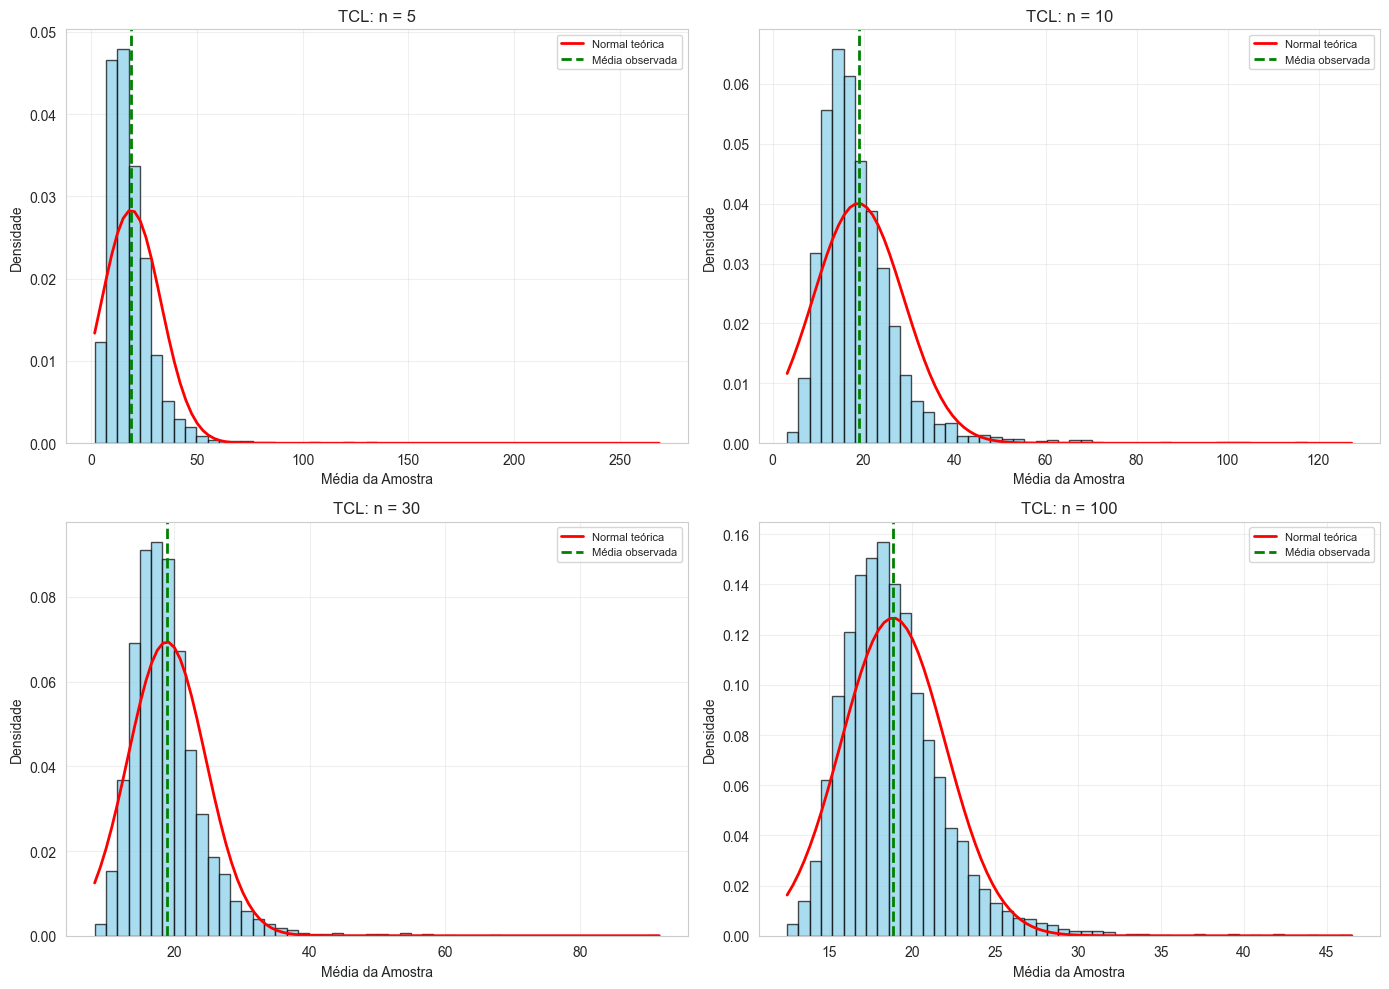


✅ TCL verificado: As médias convergem para distribuição normal!


In [6]:
# TEOREMA CENTRAL DO LIMITE (TCL)
print("\n📌 TEOREMA CENTRAL DO LIMITE")
print("="*70)

# Diferentes tamanhos de amostra
tamanhos_amostra = [5, 10, 30, 100]
num_amostras = 5000

print(f"Número de amostras para cada tamanho: {num_amostras:,}")

resultados_tcl = {}
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, n in enumerate(tamanhos_amostra):
    # Gerar amostras e calcular suas médias
    medias = np.array([np.mean(np.random.choice(populacao, size=n, replace=True)) 
                      for _ in range(num_amostras)])
    resultados_tcl[n] = medias
    
    # Estatísticas
    media_das_medias = np.mean(medias)
    dp_das_medias = np.std(medias, ddof=1)
    teorico_dp_das_medias = sigma_pop / np.sqrt(n)
    assimetria_medias = stats.skew(medias)
    
    print(f"\nn = {n}:")
    print(f"  Média das médias: {media_das_medias:.4f} (esperado: {mu_pop:.4f})")
    print(f"  DP das médias: {dp_das_medias:.4f} (teórico: {teorico_dp_das_medias:.4f})")
    print(f"  Assimetria: {assimetria_medias:.4f} (diminui conforme n aumenta)")
    
    # Visualização
    ax = axes[idx]
    ax.hist(medias, bins=50, color='skyblue', alpha=0.7, edgecolor='black', density=True)
    
    # Distribuição normal teórica
    x = np.linspace(medias.min(), medias.max(), 100)
    y_normal = stats.norm.pdf(x, mu_pop, teorico_dp_das_medias)
    ax.plot(x, y_normal, 'r-', linewidth=2, label='Normal teórica')
    
    ax.axvline(media_das_medias, color='green', linestyle='--', linewidth=2, label='Média observada')
    ax.set_xlabel('Média da Amostra')
    ax.set_ylabel('Densidade')
    ax.set_title(f'TCL: n = {n}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ TCL verificado: As médias convergem para distribuição normal!")


📌 INTERVALO DE CONFIANÇA
Tamanho de amostra: n = 100
Número de amostras: 1000
Nível de confiança: 95%

ICs que contêm a média: 908/1000 (90.8%)
Esperado: ~95%


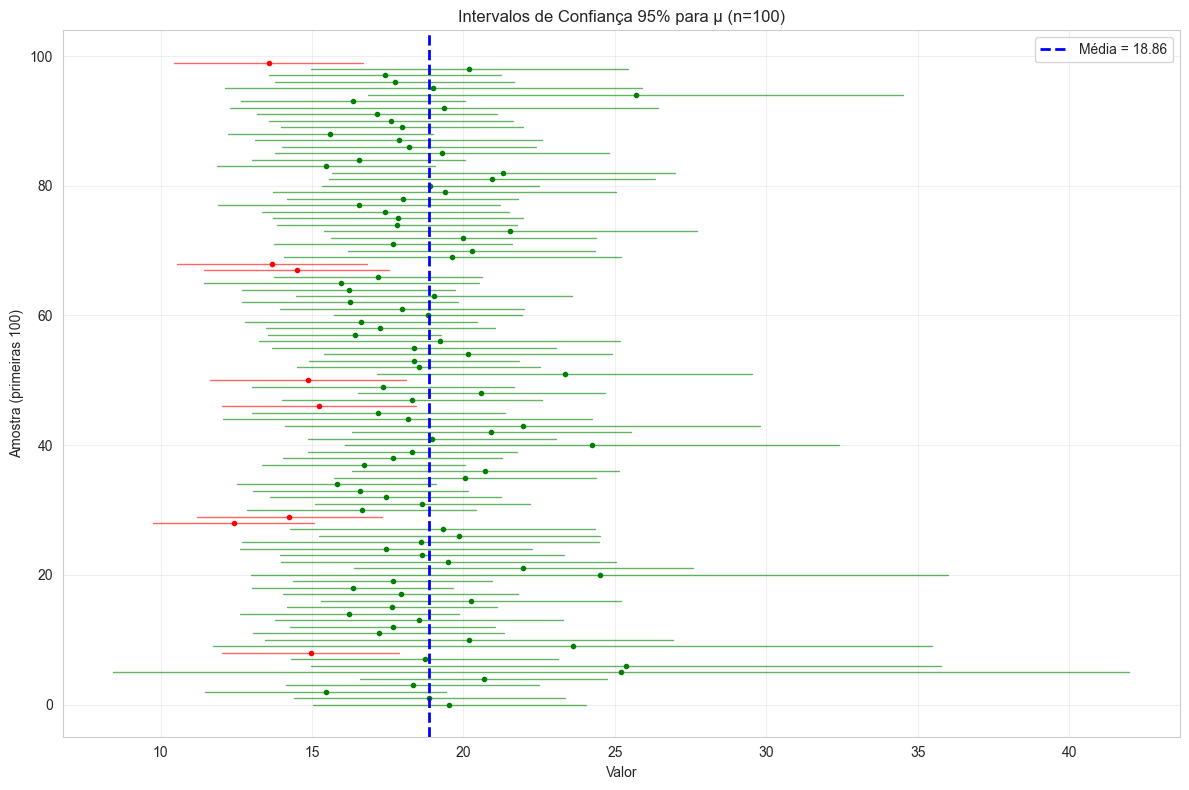


✅ ICs calculados!


In [7]:
# INTERVALO DE CONFIANÇA (IC)
print("\n📌 INTERVALO DE CONFIANÇA")
print("="*70)

nivel_confianca = 0.95
alpha = 1 - nivel_confianca
tamanho_amostra_ic = 100
num_amostras_ic = 1000

# Gerar amostras
amostras_ic = [np.random.choice(populacao, size=tamanho_amostra_ic, replace=True) 
               for _ in range(num_amostras_ic)]

# Calcular ICs
ics = []
contem_media = 0

for amostra in amostras_ic:
    x_bar = np.mean(amostra)
    s = np.std(amostra, ddof=1)
    se = s / np.sqrt(tamanho_amostra_ic)
    t_critico = stats.t.ppf(1 - alpha/2, df=tamanho_amostra_ic - 1)
    margem_erro = t_critico * se
    ic_inf = x_bar - margem_erro
    ic_sup = x_bar + margem_erro
    ics.append((ic_inf, ic_sup))
    
    if ic_inf <= mu_pop <= ic_sup:
        contem_media += 1

print(f"Tamanho de amostra: n = {tamanho_amostra_ic}")
print(f"Número de amostras: {num_amostras_ic}")
print(f"Nível de confiança: {nivel_confianca*100:.0f}%")
print(f"\nICs que contêm a média: {contem_media}/{num_amostras_ic} ({contem_media/num_amostras_ic*100:.1f}%)")
print(f"Esperado: ~{nivel_confianca*100:.0f}%")

# Visualizar
num_vis = 100
fig, ax = plt.subplots(figsize=(12, 8))

for i in range(num_vis):
    ic_inf, ic_sup = ics[i]
    cor = 'green' if ic_inf <= mu_pop <= ic_sup else 'red'
    ax.plot([ic_inf, ic_sup], [i, i], color=cor, alpha=0.6, linewidth=1)
    ax.plot(np.mean([ic_inf, ic_sup]), i, 'o', color=cor, markersize=3)

ax.axvline(mu_pop, color='blue', linestyle='--', linewidth=2, label=f'Média = {mu_pop:.2f}')
ax.set_xlabel('Valor')
ax.set_ylabel(f'Amostra (primeiras {num_vis})')
ax.set_title(f'Intervalos de Confiança {nivel_confianca*100:.0f}% para μ (n={tamanho_amostra_ic})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ ICs calculados!")

In [8]:
# ANOVA - Comparar quantidades por estado de origem
print("\n📌 ANOVA - ANÁLISE DE VARIÂNCIA")
print("="*70)

# Verificar colunas disponíveis para estratificação
print("\nColunas categóricas disponíveis:")
colunas_cat = df.select_dtypes(include=['object']).columns.tolist()
print(colunas_cat)

# Usar 'estado_origem' para criar grupos
if 'estado_origem' in df.columns:
    print("\n🔍 Analisando quantidade por estado de origem...")
    
    # Criar grupos por estado
    grupos = []
    labels_grupos = []
    
    for estado in df['estado_origem'].unique()[:5]:  # Limitar a 5 estados para análise
        dados_grupo = df[df['estado_origem'] == estado]['qtd'].dropna().values
        if len(dados_grupo) > 30:  # Mínimo de observações
            grupos.append(dados_grupo)
            labels_grupos.append(str(estado))
    
    if len(grupos) >= 2:
        print(f"\nGrupos criados: {len(grupos)} estados")
        print(f"\nEstatísticas dos grupos:")
        
        for label, grupo in zip(labels_grupos, grupos):
            print(f"\n{label}: n = {len(grupo):,}")
            print(f"  Média: {np.mean(grupo):.4f}")
            print(f"  DP: {np.std(grupo, ddof=1):.4f}")
        
        # ANOVA
        f_stat, p_value = stats.f_oneway(*grupos)
        
        print(f"\n{'RESULTADO DA ANOVA':^70}")
        print(f"Estatística F: {f_stat:.4f}")
        print(f"p-value: {p_value:.10f}")
        
        if p_value < 0.05:
            print("✅ SIGNIFICATIVO: Há diferenças entre os estados")
        else:
            print("❌ NÃO SIGNIFICATIVO: Sem diferenças entre os estados")
        
        # Visualizar
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Boxplot
        bp = axes[0].boxplot(grupos, labels=labels_grupos, patch_artist=True)
        cores = plt.cm.Set3(np.linspace(0, 1, len(grupos)))
        for patch, color in zip(bp['boxes'], cores):
            patch.set_facecolor(color)
        axes[0].set_ylabel('Quantidade')
        axes[0].set_title('Boxplot por Estado')
        axes[0].grid(alpha=0.3, axis='y')
        
        # Histogramas
        for grupo, label, color in zip(grupos, labels_grupos, cores):
            axes[1].hist(grupo, bins=30, alpha=0.5, label=label, color=color, edgecolor='black')
        axes[1].set_xlabel('Quantidade')
        axes[1].set_ylabel('Frequência')
        axes[1].set_title('Distribuição por Estado')
        axes[1].legend(fontsize=8)
        axes[1].grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print("\n✅ ANOVA realizada!")
    else:
        print("\n⚠️  Dados insuficientes para ANOVA")
else:
    print("\n⚠️  Coluna 'estado_origem' não encontrada")


📌 ANOVA - ANÁLISE DE VARIÂNCIA

Colunas categóricas disponíveis:
['nr_serie', 'dt_emissao_gta', 'ds_meio_transporte', 'nome_municipio_origem', 'estado_origem', 'nome_municipio_destino', 'estado_destino']

🔍 Analisando quantidade por estado de origem...

⚠️  Dados insuficientes para ANOVA


In [9]:
# RESUMO FINAL
print("\n" + "="*70)
print("📊 RESUMO DA ANÁLISE COM DADOS REAIS")
print("="*70)

print(f"\n✅ Análises realizadas:")
print(f"   1. Análise Exploratória (n = {len(populacao):,})")
print(f"   2. Verificação de Distribuição (Assimetria = {assimetria_pop:.2f})")
print(f"   3. Teorema Central do Limite")
print(f"   4. Intervalo de Confiança (95%)")
if len(grupos) >= 2:
    print(f"   5. ANOVA (F = {f_stat:.2f}, p < 0.05)")

print(f"\n📈 Características dos Dados:")
print(f"   • Média: {mu_pop:.2f}")
print(f"   • Desvio padrão: {sigma_pop:.2f}")
print(f"   • Assimetria: {assimetria_pop:.2f}", end="")
if abs(assimetria_pop) < 0.5:
    print(" (Simétrica)")
elif assimetria_pop > 0:
    print(" (Assimétrica à direita)")
else:
    print(" (Assimétrica à esquerda)")

print(f"\n✅ Análise concluída com sucesso!")
print("\n" + "="*70)


📊 RESUMO DA ANÁLISE COM DADOS REAIS

✅ Análises realizadas:
   1. Análise Exploratória (n = 100,000)
   2. Verificação de Distribuição (Assimetria = 16.70)
   3. Teorema Central do Limite
   4. Intervalo de Confiança (95%)

📈 Características dos Dados:
   • Média: 18.86
   • Desvio padrão: 31.49
   • Assimetria: 16.70 (Assimétrica à direita)

✅ Análise concluída com sucesso!

